<div style="display: flex; align-items: center; justify-content: center; gap: 20px;">
    <img src="https://www.tinderpressroom.com/download/Flame+Gradient+RGB.png" alt="Image Gauche" style="width: 100px; height: auto;">
    <img src="https://www.tinderpressroom.com/download/Flame+Gradient+RGB.png" alt="Image Gauche" style="width: 100px; height: auto;">
    <div style="text-align: center;">
        <h1>
            <span style="font-weight: bold; color: #FF5864; text-decoration: underline;">
                Tinder_Speed_Dating_Dataset
            </span>
        </h1>
    </div>
    <img src="https://www.tinderpressroom.com/download/Flame+Gradient+RGB.png" alt="Image Droite" style="width: 100px; height: auto;">
    <img src="https://www.tinderpressroom.com/download/Flame+Gradient+RGB.png" alt="Image Gauche" style="width: 100px; height: auto;">
</div>


The main goal of this exploratory data analysis (EDA) is to investigate specific aspects of the dataset in order to identify characteristics that might contribute to the appearance of a match. Throughout this notebook, a match (1) represents mutual attraction validated by both partners after the date, while a non-match (0) indicates that at least one partner did not validate the match.

The src folder contains the dataset file Speed_Dating_Data.csv and a corresponding documentation file Speed_Dating_Data_Key.pdf summarizing the dataset’s variables. A French translation is also available as Speed_Dating_Data_Key_FR.pdf.

# 1. Data Retrieval


In [1]:
# Pandas Import and dataframe retrieval

import pandas as pd
df = pd.read_csv("src/Speed_Dating_Data.csv", encoding="ISO-8859-1")

In [2]:
# Overall Dataframe Visualization

df.head(5)

,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.0,0,1,1,1,10,7,NaN,4,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
1,1,1.0,0,1,1,1,10,7,NaN,3,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
2,1,1.0,0,1,1,1,10,7,NaN,10,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
3,1,1.0,0,1,1,1,10,7,NaN,5,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
4,1,1.0,0,1,1,1,10,7,NaN,7,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN


In [3]:
# Visualisation de la taille

df.shape

(8378, 195)

The dataset is complex and contains a large number of features; however, only a selected subset of variables will be examined in detail throughout this analysis.

# 2. Quick analysis - Matches rate

## 2.1 Data reduction

In [140]:
# First check - number of records per wave

df[['wave']].value_counts()

wave
21      968
11      882
9       800
14      720
15      684
4       648
2       608
7       512
19      450
12      392
17      280
3       200
8       200
1       200
5       190
13      180
10      162
16       96
20       84
18       72
6        50
Name: count, dtype: int64

According to the provided information, we expected a specific number of records. For instance, Wave 1 with 10 males and 10 females should result in 100 dates, and Wave 2 with 16 males and 19 females should produce 304, and so on.

However, the dataset contains exactly twice as many rows as expected based on the number of participants per wave (e.g., 200 for Wave 1, 608 for Wave 2). This suggests potential redundancy or duplication in the data. To explore this further, we’ll take a closer look at the smallest wave—Wave 6 where 25 dates took place (5 males and 5 females) but 50 rows are recorded.

In [141]:
# Filter the dataset to keep only wave 6, and some particular elements (ids and match)
subset_wave6 = df[df['wave'] == 6][['wave', 'iid', 'pid','match']]

# Check the good application
subset_wave6.shape


(50, 4)

In [142]:
# Create a new column, that is a tuple including both ids, in ascending order
subset_wave6['iid_pid'] = subset_wave6.apply(lambda row: tuple(sorted([row['iid'], row['pid']])), axis=1)

# Check the good application
subset_wave6.head()


,wave,iid,pid,match,iid_pid
1846,6,132,137.0,0,"(132.0, 137.0)"
1847,6,132,138.0,0,"(132.0, 138.0)"
1848,6,132,139.0,0,"(132.0, 139.0)"
1849,6,132,140.0,1,"(132.0, 140.0)"
1850,6,132,141.0,0,"(132.0, 141.0)"


In [143]:
# Delete the tuple duplicates would remove a potential redundancy with iid_pid

subset_wave6 = subset_wave6.drop_duplicates(['iid_pid'])

subset_wave6.shape

(25, 5)

The redundancy is confirmed: a single date results in two separate records. However, this duplication cannot be simply removed, as the dataset only provides detailed information for the iid and not the pid. Removing duplicates would therefore lead to an irreversible loss of valuable data.

## 2.2 Overall match rate

Let's calculate the overall match rate to gain a clearer understanding of the dataset, as this feature is the most important one—the core focus of our project!

In [144]:
# Overall mean (rounded)
df["match"].mean().round(2)

0.16

Approximately 16% of dates resulted in a match. From a business perspective—especially for a company like Tinder—this insight is critical: it means that only a small fraction of first dates lead to mutual interest. Understanding and optimizing this match rate is essential, as it directly impacts user satisfaction, engagement, and ultimately, the platform's success in delivering meaningful connections. (no impact of record duplication on this rate)

## 2.3 Matches per wave

Let’s take a closer look to explore the potential impact across the different waves.µ

In [145]:
# Creation of a specific dataframe showing matches per wave
match_per_wave = df[['wave', 'match']].groupby('wave').agg(
    nb_match=('match', 'sum'),
    nb_dates=('match', 'count'),
    match_rate=('match', 'mean'),
).reset_index()

# Round match_rate
match_per_wave['match_rate'] = match_per_wave['match_rate'].round(2)

# Visualization in ascending order
match_per_wave.sort_values('match_rate', ascending = False).reset_index(drop=True)


,wave,nb_match,nb_dates,match_rate
0,1,62,200,0.31
1,5,54,190,0.28
2,16,24,96,0.25
3,4,130,648,0.20
4,6,10,50,0.20
5,10,30,162,0.19
6,15,126,684,0.18
7,8,36,200,0.18
8,13,32,180,0.18
9,14,126,720,0.18


We observe significant differences between the waves, with match rates ranging from 0.08 to 0.31 — a variation by a factor of nearly four!

In [146]:
# Let's visualize this data

import plotly.express as px

fig = px.bar( match_per_wave,
        y="match_rate",
        x="wave",
        title="<b>Match_rate per wave<b>")

# Update title layout to center it
fig.update_layout(
    title={'x': 0.5, 'xanchor': 'center'}
)

Some quick conclusions: there are significant disparities in match rates across waves, but no clear upward or downward trend over time. (no impact of record duplication on these rates)

# 3. Interesting Insights to Explore

From a business perspective, it is particularly valuable to explore certain aspects of the dataset in greater depth to determine whether specific variables among the many features collected could help explain or even predict higher match rates. Identifying such drivers of success would provide actionable insights to optimize future waves of events—whether by refining participant selection, adjusting event formats, or tailoring user experiences—ultimately aiming to improve the overall effectiveness and impact of the dating platform.

To guide this exploration, we will focus on fout key questions:

- Does the age difference between two participants influence the likelihood of a match?
- What personal traits and self-perceptions influence your chances of being chosen?
- Are shared hobbies between participants a determining factor?
- And finally, does fatigue over the course of the evening affect decision-making?

These questions will help uncover potential levers to enhance future event performance.

## 3.1 Age Gap: Does It Matter?

In [147]:
# Creation of a subset_age to show age per id
subset_age = df[['iid', 'age']].drop_duplicates(subset='iid')

# Rename iid column as id
subset_age = subset_age.rename(columns={'iid': 'id'})

In [148]:
# Creation of a subset_age_gap to perform the analysis
subset_age_gap = df[['iid', 'pid', 'match']].copy()

In [149]:
# Necessary formatting

subset_age["id"] = subset_age["id"].astype("Int64")
subset_age["age"] = subset_age["age"].astype("Int64")
subset_age_gap["iid"] = subset_age_gap["iid"].astype("Int64")
subset_age_gap["pid"] = subset_age_gap["pid"].astype("Int64")

In [150]:
# Junctions to add age_iid on subset_age_gap

subset_age_gap = subset_age_gap.merge(subset_age, left_on="iid", right_on="id", how="left")
subset_age_gap = subset_age_gap.rename(columns={"age": "age_iid"})
subset_age_gap = subset_age_gap.drop(columns=["id"]) # redundant with iid

subset_age_gap.head()

,iid,pid,match,age_iid
0,1,11,0,21
1,1,12,0,21
2,1,13,1,21
3,1,14,1,21
4,1,15,1,21


In [151]:
# Junctions to add age_pid on subset_age_gap

subset_age_gap = subset_age_gap.merge(subset_age, left_on="pid", right_on="id", how="left")
subset_age_gap = subset_age_gap.rename(columns={"age": "age_pid"})
subset_age_gap = subset_age_gap.drop(columns=["id"]) # redundant with pid

subset_age_gap.head()

,iid,pid,match,age_iid,age_pid
0,1,11,0,21,27
1,1,12,0,21,22
2,1,13,1,21,22
3,1,14,1,21,23
4,1,15,1,21,24


In [152]:
# Creation of the colulmn age_diff
subset_age_gap["age_diff"] = (subset_age_gap["age_iid"] - subset_age_gap["age_pid"]).abs()

# Reorder the dataframe
subset_age_gap = subset_age_gap[["iid", "age_iid", "pid", "age_pid", "age_diff", "match"]]

# Visualize the dataframe
subset_age_gap.head()

,iid,age_iid,pid,age_pid,age_diff,match
0,1,21,11,27,6,0
1,1,21,12,22,1,0
2,1,21,13,22,1,1
3,1,21,14,23,2,1
4,1,21,15,24,3,1


The dataset is now clarified to enable analysis.

In [153]:
# Creation of categories
def assign_group(age_diff):
    if age_diff < 3:
        return '0-2years'
    elif age_diff < 6:
        return '3-5years'
    elif age_diff < 9:
        return '6-8years'
    else:
        return '9+years'

subset_age_gap['group_age_diff'] = subset_age_gap['age_diff'].apply(assign_group)
        

# Display the new dataset
subset_age_gap.head()

,iid,age_iid,pid,age_pid,age_diff,match,group_age_diff
0,1,21,11,27,6,0,6-8years
1,1,21,12,22,1,0,0-2years
2,1,21,13,22,1,1,0-2years
3,1,21,14,23,2,1,0-2years
4,1,21,15,24,3,1,3-5years


In [154]:
# Match_rate per categories _ simple dataframe creation

age_group_analysis = subset_age_gap.groupby('group_age_diff').agg(
    meeting_count=('group_age_diff', 'size'),
    match_count=('match', 'sum')
).reset_index()

age_group_analysis["match_rate"] = (age_group_analysis['match_count'] / age_group_analysis['meeting_count']).round(2)
age_group_analysis["non_match_count"] = age_group_analysis['meeting_count'] - age_group_analysis['match_count']

# Display the analysis_table
age_group_analysis

,group_age_diff,meeting_count,match_count,match_rate,non_match_count
0,0-2years,3512,664,0.19,2848
1,3-5years,2848,454,0.16,2394
2,6-8years,1272,166,0.13,1106
3,9+years,746,96,0.13,650


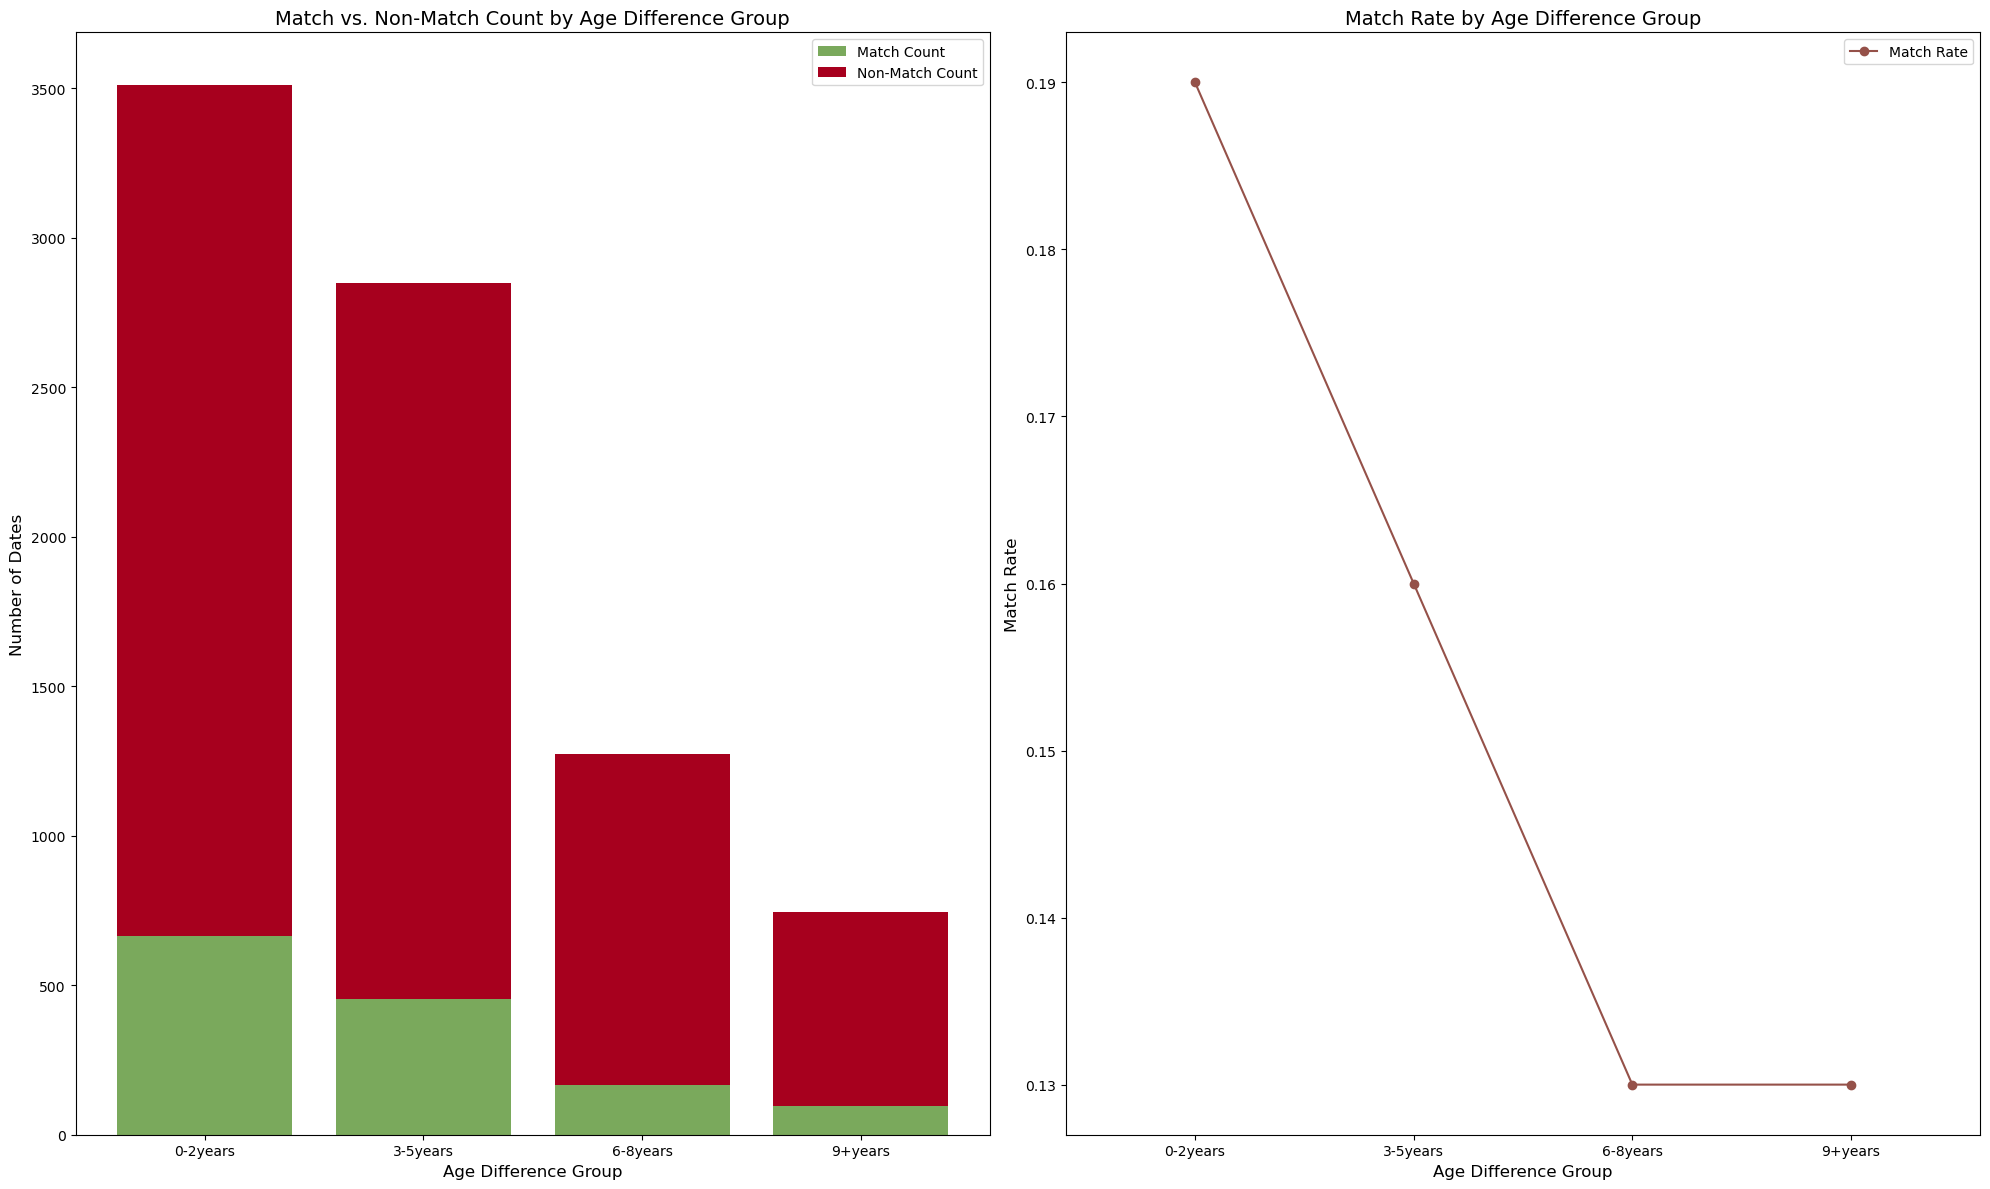

In [155]:
# Visualization of match statistics by age difference group

import matplotlib.pyplot as plt

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 12), sharex=True)

x = range(len(age_group_analysis['group_age_diff']))
width = 0.8  # Width of the bars

# Chart 1: Stacked bar chart for matches and non-matches
# Bar for match counts
ax1.bar(
    x,
    age_group_analysis['match_count'],
    width,
    label='Match Count',
    color='#7AA95C'
)

# Bar for non-match counts stacked on top of match counts
ax1.bar(
    x,
    age_group_analysis['non_match_count'],
    width,
    bottom=age_group_analysis['match_count'],
    label='Non-Match Count',
    color='#A7001E'
)

# Add labels and title to the first chart
ax1.set_ylabel('Number of Dates', fontsize=12)
ax1.set_xlabel('Age Difference Group', fontsize=12)
ax1.set_title('Match vs. Non-Match Count by Age Difference Group', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(age_group_analysis['group_age_diff'], fontsize=10)
ax1.legend(loc='upper right')

# Chart 2: Line plot for match rate
ax2.plot(
    x, 
    age_group_analysis['match_rate'], 
    color='#955149', 
    marker='o', 
    label='Match Rate'
)

# Add labels and title to the second chart
ax2.set_ylabel('Match Rate', fontsize=12)
ax2.set_xlabel('Age Difference Group', fontsize=12)
ax2.set_title('Match Rate by Age Difference Group', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels(age_group_analysis['group_age_diff'], fontsize=10)
ax2.legend(loc='upper right')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()


By grouping the age differences, a clear trend emerges: the smaller the age gap between two participants on a date, the higher their chances of matching. Based on this insight, it may be worthwhile to pre-select participants within similar age ranges from the outset, as this could significantly increase the likelihood of mutual interest and improve overall match rates.

## 3.2 What Makes You Likable?

The analysis will focus on both the initial and perceived characteristics of the individual identified by iid, and the decision made by the other participant regarding them, as captured by the dec_o column.

In [44]:
# Create specific subset to perform the analysis

columns_matchworthy = [
    "iid", "age", "field_cd", "race", "goal", "date", # a few general and relevant characteristics to analyze
    "attr3_1", "sinc3_1", "intel3_1", "fun3_1", "amb3_1",  # self-evaluation
    "attr5_1", "sinc5_1", "intel5_1", "fun5_1", "amb5_1",  # perceived by others
    "dec_o"  # decision of the other participant
]

subset_matchworthy = df[columns_matchworthy].dropna(subset=["dec_o"])


In [45]:
# Aggregate by iid to avoid bias introduced by multiple dates per participant.

# Colonnes to keep (always the same value)
cols_to_copy = [col for col in columns_matchworthy if col not in ["iid", "dec_o"]]

# Iid aggregation
agg_matchworthy = subset_matchworthy.groupby("iid").agg(
    nb_dates=("dec_o", "count"),
    nb_yes_received=("dec_o", "sum"),
    **{col: (col, "first") for col in cols_to_copy}
).reset_index()

# "Yes-rate" calculation
agg_matchworthy["yes_rate"] = agg_matchworthy["nb_yes_received"] / agg_matchworthy["nb_dates"]


In [46]:
# Visualizing the analysis dataset

agg_matchworthy.head()

,iid,nb_dates,nb_yes_received,age,field_cd,race,goal,date,attr3_1,sinc3_1,intel3_1,fun3_1,amb3_1,attr5_1,sinc5_1,intel5_1,fun5_1,amb5_1,yes_rate
0,1,10,5,21.0,1.0,4.0,2.0,7.0,6.0,8.0,8.0,8.0,7.0,NaN,NaN,NaN,NaN,NaN,0.5
1,2,10,6,24.0,1.0,2.0,1.0,5.0,7.0,5.0,8.0,10.0,3.0,NaN,NaN,NaN,NaN,NaN,0.6
2,3,10,5,25.0,2.0,2.0,6.0,3.0,8.0,9.0,9.0,8.0,8.0,NaN,NaN,NaN,NaN,NaN,0.5
3,4,10,6,23.0,1.0,2.0,1.0,5.0,7.0,8.0,7.0,9.0,8.0,NaN,NaN,NaN,NaN,NaN,0.6
4,5,10,3,21.0,1.0,2.0,2.0,4.0,6.0,3.0,10.0,6.0,8.0,NaN,NaN,NaN,NaN,NaN,0.3


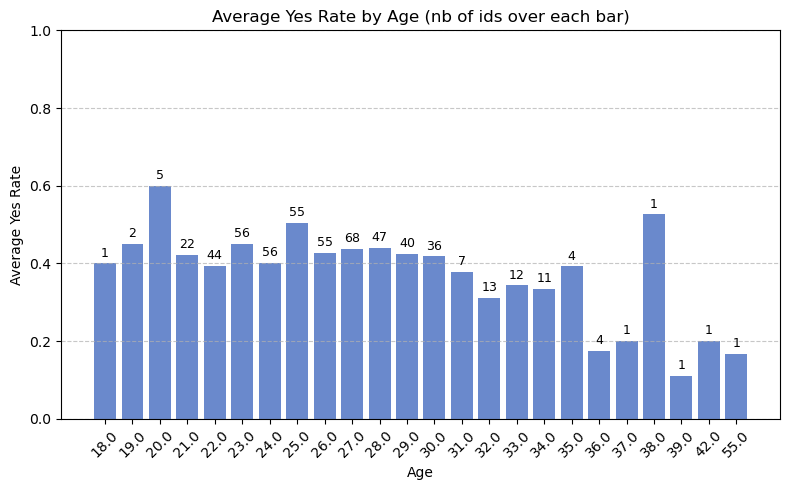

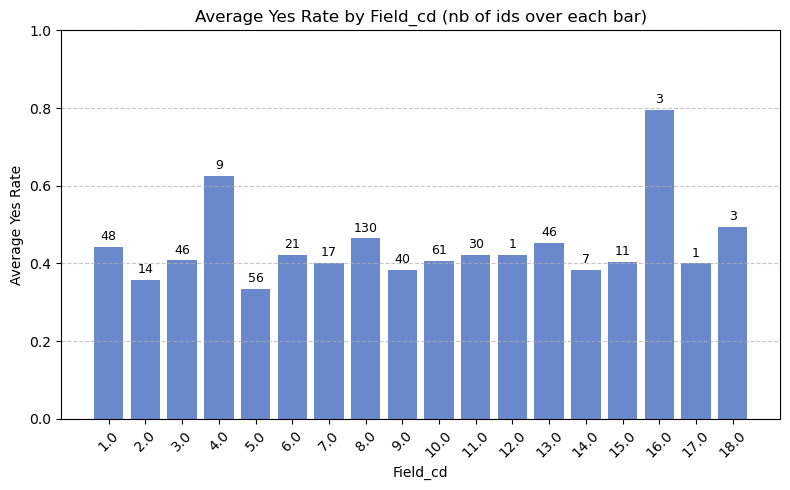

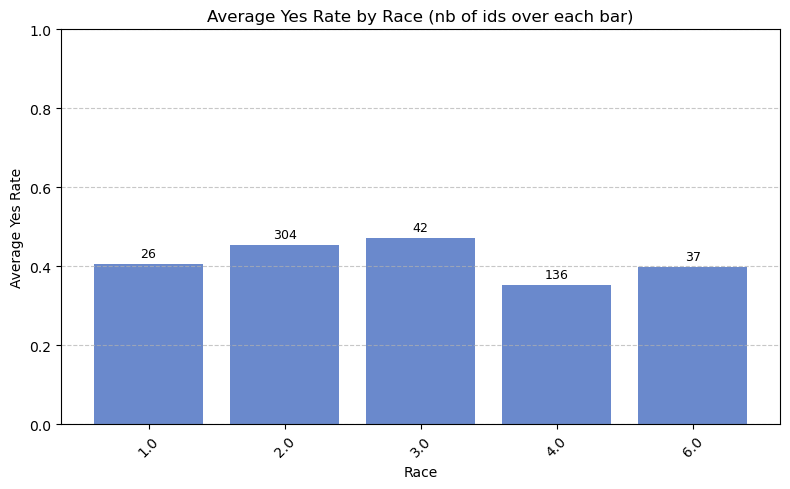

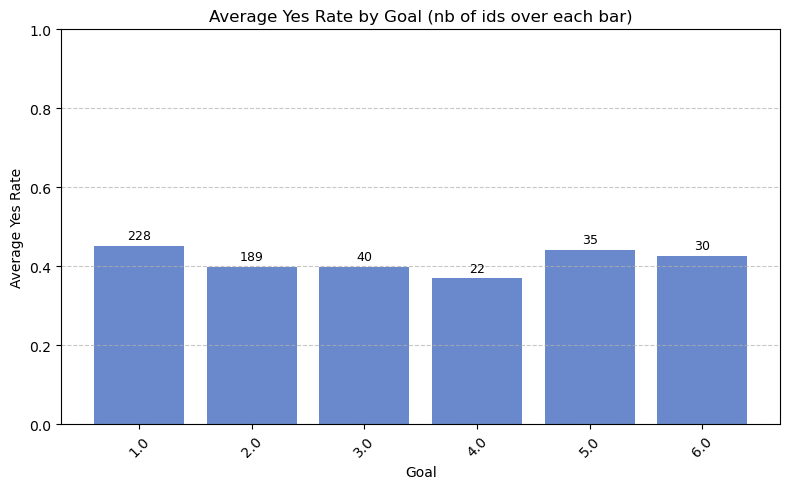

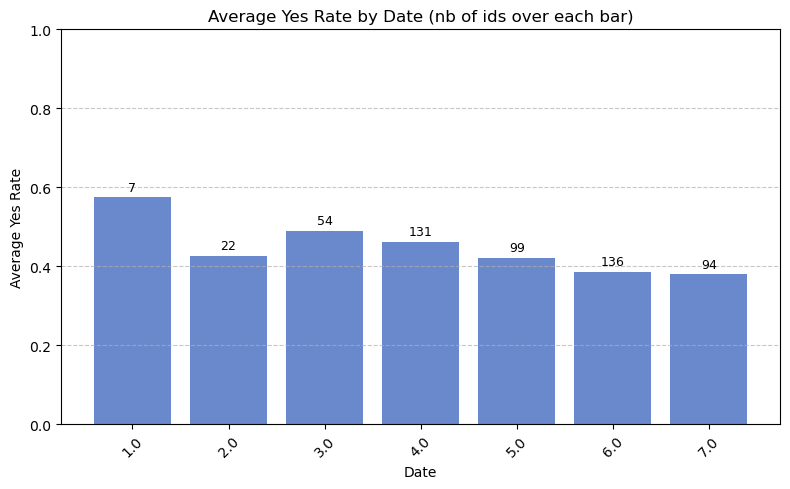

In [47]:
# Yes_rate per general characteristic

cols_to_plot = ["age", "field_cd", "race", "goal", "date"]

for col in cols_to_plot:
    if agg_matchworthy[col].notna().sum() > 0:
        plt.figure(figsize=(8, 5))

        # Calculation of number of ids per value
        group_stats = agg_matchworthy.groupby(col)["yes_rate"].agg(["mean", "count"])
        bars = plt.bar(group_stats.index.astype(str), group_stats["mean"], color="#6A89CC")

        # Display the number over each bar
        for bar, count in zip(bars, group_stats["count"]):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f'{count}', 
                     ha='center', va='bottom', fontsize=9)

        plt.title(f"Average Yes Rate by {col.capitalize()} (nb of ids over each bar)")
        plt.ylabel("Average Yes Rate")
        plt.xlabel(col.capitalize())
        plt.xticks(rotation=45)
        plt.ylim(0, 1)  # Pour s'assurer que les labels ne dépassent pas
        plt.grid(axis="y", linestyle="--", alpha=0.7)
        plt.tight_layout()
        plt.show()



As a reminder, the yes_rate of a participant represents the percentage of positive decisions they received from others following their dates. 

Overall, we observe a slight decline in yes_rate among individuals over 30 years old, and a more noticeable drop after the age of 35—although the small sample size in that age range prevents us from drawing definitive conclusions.

Among the 18 fields of study (field_cd), two stand out positively: #4 (Medicine) and #16 (Languages). In contrast, #5 (Engineering) appears to perform slightly below average. However, it's important to note that very few individuals were associated with category 16, so results should be interpreted with caution.

When it comes to race and dating goals, no clear or consistent patterns emerge.

Finally, looking at the date variable—which reflects how frequently a participant goes on dates—it seems that those with lower values (i.e., those who date more frequently) tend to have higher yes rates, suggesting that regular exposure may slightly enhance likability.

In [48]:
# Comeback to agg_matchworthy

agg_matchworthy.head()

,iid,nb_dates,nb_yes_received,age,field_cd,race,goal,date,attr3_1,sinc3_1,intel3_1,fun3_1,amb3_1,attr5_1,sinc5_1,intel5_1,fun5_1,amb5_1,yes_rate
0,1,10,5,21.0,1.0,4.0,2.0,7.0,6.0,8.0,8.0,8.0,7.0,NaN,NaN,NaN,NaN,NaN,0.5
1,2,10,6,24.0,1.0,2.0,1.0,5.0,7.0,5.0,8.0,10.0,3.0,NaN,NaN,NaN,NaN,NaN,0.6
2,3,10,5,25.0,2.0,2.0,6.0,3.0,8.0,9.0,9.0,8.0,8.0,NaN,NaN,NaN,NaN,NaN,0.5
3,4,10,6,23.0,1.0,2.0,1.0,5.0,7.0,8.0,7.0,9.0,8.0,NaN,NaN,NaN,NaN,NaN,0.6
4,5,10,3,21.0,1.0,2.0,2.0,4.0,6.0,3.0,10.0,6.0,8.0,NaN,NaN,NaN,NaN,NaN,0.3


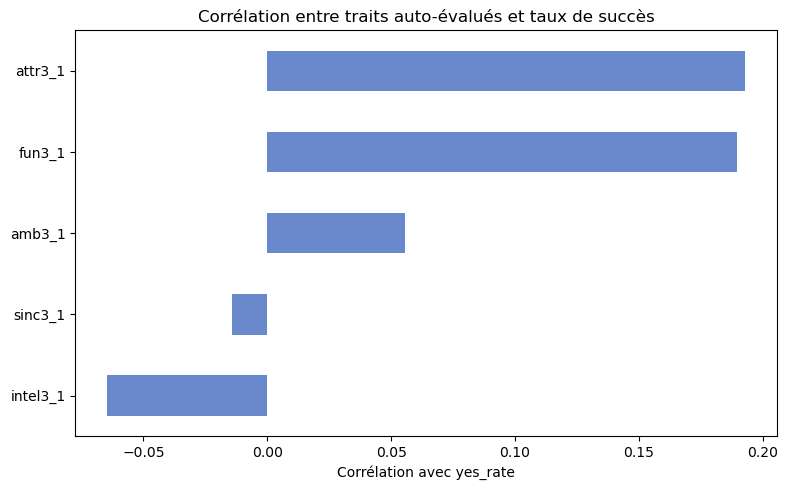

In [49]:
import matplotlib.pyplot as plt

# Sélection des colonnes de traits auto-évalués
traits_self = ["attr3_1", "sinc3_1", "intel3_1", "fun3_1", "amb3_1"]

# Calcul des corrélations avec yes_rate
correlations = agg_matchworthy[traits_self + ["yes_rate"]].corr()["yes_rate"].drop("yes_rate")

# Affichage du barplot
plt.figure(figsize=(8, 5))
correlations.sort_values().plot(kind="barh", color="#6A89CC")
plt.title("Corrélation entre traits auto-évalués et taux de succès")
plt.xlabel("Corrélation avec yes_rate")
plt.tight_layout()
plt.show()


C:\Users\valen\AppData\Local\Temp\ipykernel_24332\3964654969.py:20: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\valen\AppData\Local\Temp\ipykernel_24332\3964654969.py:28: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



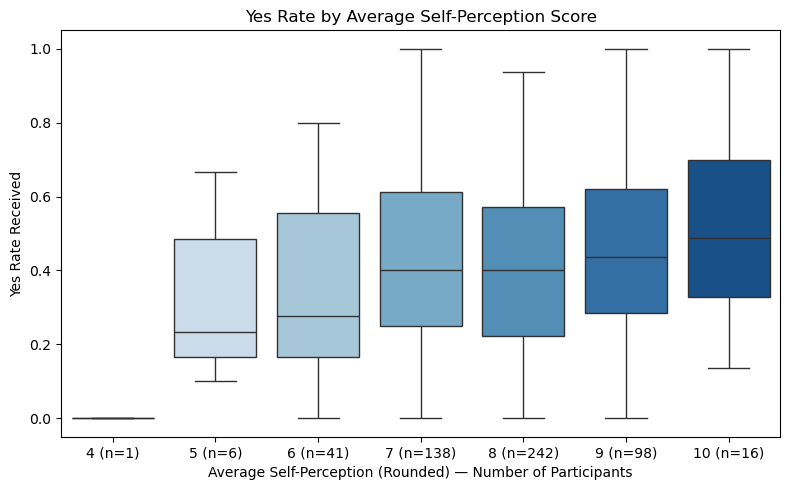

In [56]:
# Define the self-rated trait columns
traits_self = ["attr3_1", "sinc3_1", "intel3_1", "fun3_1", "amb3_1"]

# Create a new column with the average self-rating
agg_matchworthy["self_score"] = agg_matchworthy[traits_self].mean(axis=1)

# Round it to simplify grouping in visualizations
agg_matchworthy["self_score_rounded"] = agg_matchworthy["self_score"].round()

import seaborn as sns
import matplotlib.pyplot as plt

# Calculer les effectifs par groupe
counts = agg_matchworthy["self_score_rounded"].value_counts().sort_index()

# Générer les labels : par ex. "7.0 (n=24)"
xtick_labels = [f"{score:.0f} (n={count})" for score, count in counts.items()]

plt.figure(figsize=(8, 5))
ax = sns.boxplot(
    x="self_score_rounded",
    y="yes_rate",
    data=agg_matchworthy,
    palette="Blues"
)

# Remplacer les ticks x par les labels avec effectif
ax.set_xticklabels(xtick_labels)

# Titres
plt.title("Yes Rate by Average Self-Perception Score")
plt.xlabel("Average Self-Perception (Rounded) — Number of Participants")
plt.ylabel("Yes Rate Received")
plt.tight_layout()
plt.show()




As a reminder, the attr3_1 to amb3_1 variables reflect how participants rate themselves on key personal traits—such as attractiveness, sincerity, intelligence, fun, and ambition—on a scale from 1 (very poor) to 10 (excellent). 

A higher self-esteem appears to be associated with receiving more "yes" responses on average, suggesting that individuals who view themselves positively may project greater confidence and make a more favorable impression.

## 3.3 Do Shared Interests Drive Connection?

In [4]:
# Creation of a subset_hobbies to show hobbies per id
hobbies_columns =['sports', 'tvsports', 'exercise', 'dining', 'museums', 'art', 'hiking', 'gaming', 'clubbing', 'reading', 'tv', 'theater', 'movies', 'concerts', 'music', 'shopping', 'yoga']
subset_hobbies = df[['iid'] + hobbies_columns].drop_duplicates(subset='iid')

# Rename iid column as id
subset_hobbies = subset_hobbies.rename(columns={'iid': 'id'})

In [5]:
# Creation of a subset_hobbies_complete to perform the analysis
subset_hobbies_complete = df[['iid', 'pid', 'match']].copy()

# Necessary formatting

subset_hobbies_complete["iid"] = subset_hobbies_complete["iid"].astype("Int64")
subset_hobbies_complete["pid"] = subset_hobbies_complete["pid"].astype("Int64")

In [6]:
# Junctions to add hobbies_iid on subset_hobbies_complete

subset_hobbies_complete = subset_hobbies_complete.merge(subset_hobbies, left_on="iid", right_on="id", how="left")
subset_hobbies_complete = subset_hobbies_complete.drop(columns=["id"]) # redundant with iid

# Rename new columns
rename_dict_iid = {col: f"{col}_iid" for col in hobbies_columns}
subset_hobbies_complete = subset_hobbies_complete.rename(columns=rename_dict_iid)

subset_hobbies_complete.head()

,iid,pid,match,sports_iid,tvsports_iid,exercise_iid,dining_iid,museums_iid,art_iid,hiking_iid,gaming_iid,clubbing_iid,reading_iid,tv_iid,theater_iid,movies_iid,concerts_iid,music_iid,shopping_iid,yoga_iid
0,1,11,0,9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0
1,1,12,0,9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0
2,1,13,1,9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0
3,1,14,1,9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0
4,1,15,1,9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0


In [7]:
# Junctions to add hobbies_pid on subset_hobbies_complete

subset_hobbies_complete = subset_hobbies_complete.merge(subset_hobbies, left_on="pid", right_on="id", how="left")
subset_hobbies_complete = subset_hobbies_complete.drop(columns=["id"]) # redundant with pid

# Rename new columns
rename_dict_pid = {col: f"{col}_pid" for col in hobbies_columns}
subset_hobbies_complete = subset_hobbies_complete.rename(columns=rename_dict_pid)

subset_hobbies_complete.head()

,iid,pid,match,sports_iid,tvsports_iid,exercise_iid,dining_iid,museums_iid,art_iid,hiking_iid,...,gaming_pid,clubbing_pid,reading_pid,tv_pid,theater_pid,movies_pid,concerts_pid,music_pid,shopping_pid,yoga_pid
0,1,11,0,9.0,2.0,8.0,9.0,1.0,1.0,5.0,...,5.0,4.0,9.0,2.0,4.0,8.0,7.0,8.0,5.0,1.0
1,1,12,0,9.0,2.0,8.0,9.0,1.0,1.0,5.0,...,3.0,5.0,6.0,6.0,4.0,7.0,7.0,9.0,5.0,5.0
2,1,13,1,9.0,2.0,8.0,9.0,1.0,1.0,5.0,...,7.0,7.0,6.0,8.0,10.0,8.0,9.0,9.0,8.0,1.0
3,1,14,1,9.0,2.0,8.0,9.0,1.0,1.0,5.0,...,8.0,8.0,6.0,7.0,3.0,10.0,6.0,8.0,6.0,1.0
4,1,15,1,9.0,2.0,8.0,9.0,1.0,1.0,5.0,...,7.0,9.0,8.0,6.0,9.0,9.0,6.0,7.0,2.0,1.0


In [8]:
# Difference between hobbies
for hobby in hobbies_columns:
    subset_hobbies_complete[f"{hobby}_diff"] = (subset_hobbies_complete[f"{hobby}_iid"] - subset_hobbies_complete[f"{hobby}_pid"]).abs().astype("Int64")

# Keep only this difference
diff_columns = [f"{hobby}_diff" for hobby in hobbies_columns]
subset_hobbies_gap = subset_hobbies_complete[['iid','pid','match'] + diff_columns]

subset_hobbies_gap.head()

,iid,pid,match,sports_diff,tvsports_diff,exercise_diff,dining_diff,museums_diff,art_diff,hiking_diff,gaming_diff,clubbing_diff,reading_diff,tv_diff,theater_diff,movies_diff,concerts_diff,music_diff,shopping_diff,yoga_diff
0,1,11,0,1,5,6,3,6,4,0,4,1,3,7,3,2,3,1,3,0
1,1,12,0,0,5,1,1,6,5,2,2,0,0,3,3,3,3,0,3,4
2,1,13,1,2,6,6,0,4,5,1,6,2,0,1,9,2,1,0,0,0
3,1,14,1,1,4,0,1,2,2,5,7,3,0,2,2,0,4,1,2,0
4,1,15,1,0,5,1,2,3,2,1,6,4,2,3,8,1,4,2,6,0


In [9]:
# Creation of subset mean_hobbies_gap

subset_hobbies_gap.loc[:,"mean_hobbies_diff"] = subset_hobbies_gap[
    [col for col in subset_hobbies_gap.columns if col.endswith("_diff")]
].mean(axis=1)

# Keep only necessary columns
subset_mean_hobbies_gap = subset_hobbies_gap[["iid", "pid", "match", "mean_hobbies_diff"]].copy()

subset_mean_hobbies_gap.head()

C:\Users\valen\AppData\Local\Temp\ipykernel_24332\4228556056.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_hobbies_gap.loc[:,"mean_hobbies_diff"] = subset_hobbies_gap[


,iid,pid,match,mean_hobbies_diff
0,1,11,0,3.058824
1,1,12,0,2.411765
2,1,13,1,2.647059
3,1,14,1,2.117647
4,1,15,1,2.941176


In [10]:
# Visualization of mean_differences / box plot

import plotly.graph_objects as go
fig = go.Figure()

# Boxplot non-matchs (match == 0)
fig.add_trace(go.Box(
    x=subset_mean_hobbies_gap[subset_mean_hobbies_gap["match"] == 0]["match"],
    y=subset_mean_hobbies_gap[subset_mean_hobbies_gap["match"] == 0]["mean_hobbies_diff"],
    name="Non-Match",
    marker_color='#A7001E'
))

# Boxplot matchs (match == 1)
fig.add_trace(go.Box(
    x=subset_mean_hobbies_gap[subset_mean_hobbies_gap["match"] == 1]["match"],
    y=subset_mean_hobbies_gap[subset_mean_hobbies_gap["match"] == 1]["mean_hobbies_diff"],
    name="Match",
    marker_color='#7AA95C'
))

# Update plot layout
fig.update_layout(
    title="<b>Common Hobby Comparison for Matches and Non-Matches</b>",
    title_x=0.5,
    width=1200,
    height=700,
    showlegend=False,
    template="plotly_white",
    xaxis=dict(
        tickvals=[0, 1],
        ticktext=["<b>Non-Match", "<b>Match"]
    ),
    yaxis=dict(
        title="<b>Mean Hobby Difference</b>"
    )
)

fig.show()



There is no clear or significant difference between the two distributions, suggesting that the average hobby similarity does not strongly influence the likelihood of a match.
It is likely not meaningful to consider overall hobby similarity for a brief date; what may matter more is compatibility on a few key hobbies that individuals personally value most.

In [11]:
# Comeback to subset_hobbies

subset_hobbies.head()

,id,sports,tvsports,exercise,dining,museums,art,hiking,gaming,clubbing,reading,tv,theater,movies,concerts,music,shopping,yoga
0,1,9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0
10,2,3.0,2.0,7.0,10.0,8.0,6.0,3.0,5.0,8.0,10.0,1.0,9.0,8.0,7.0,8.0,3.0,1.0
20,3,3.0,8.0,7.0,8.0,5.0,5.0,8.0,4.0,5.0,7.0,8.0,7.0,7.0,7.0,5.0,8.0,7.0
30,4,1.0,1.0,6.0,7.0,6.0,7.0,7.0,5.0,7.0,7.0,7.0,9.0,7.0,8.0,7.0,1.0,8.0
40,5,7.0,4.0,7.0,7.0,6.0,8.0,6.0,6.0,8.0,6.0,8.0,6.0,6.0,3.0,7.0,8.0,3.0


In [12]:
# Determination of top5 hobbies per id

# Function creation
def top5_binary(row):
    top5 = row[hobbies_columns].rank(method='first', ascending=False) <= 5
    return top5.astype(int)

# Apply to each line to create a binary_top5 dataframe
binary_top5 = subset_hobbies.copy()
binary_top5[hobbies_columns] = subset_hobbies[hobbies_columns].apply(top5_binary, axis=1)

binary_top5.head()

,id,sports,tvsports,exercise,dining,museums,art,hiking,gaming,clubbing,reading,tv,theater,movies,concerts,music,shopping,yoga
0,1,1,0,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0
10,2,0,0,0,1,1,0,0,0,1,1,0,1,0,0,0,0,0
20,3,0,1,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0
30,4,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,1
40,5,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0


In [13]:
# Creation of shared_hobbies table

match_id_table = df[['iid', 'pid', 'match']].copy()

# Necessary formatting

match_id_table["iid"] = match_id_table["iid"].astype("Int64")
match_id_table["pid"] = match_id_table["pid"].astype("Int64")

# Merge to add top5 per id
shared_hobbies = match_id_table.merge(binary_top5, left_on='iid', right_on='id', how='left')
shared_hobbies = shared_hobbies.merge(binary_top5, left_on='pid', right_on='id', how='left', suffixes=('_iid', '_pid'))

# Sum for each hobby
for hobby in hobbies_columns:
    shared_hobbies[f"{hobby}"] = shared_hobbies[f"{hobby}_iid"] + shared_hobbies[f"{hobby}_pid"]

# Delete initial top 5 to see the combination
cols_to_drop = [f"{hobby}_iid" for hobby in hobbies_columns] + [f"{hobby}_pid" for hobby in hobbies_columns]
shared_hobbies = shared_hobbies.drop(columns=cols_to_drop)

# Identify hobbies
nb_of_same_hobbies = [f"{hobby}" for hobby in hobbies_columns]

# Sum the number of hobbies = 2
shared_hobbies["nb_shared_top_hobbies"] = (shared_hobbies[nb_of_same_hobbies] == 2).sum(axis=1)

shared_hobbies.head()


,iid,pid,match,id_iid,id_pid,sports,tvsports,exercise,dining,museums,...,clubbing,reading,tv,theater,movies,concerts,music,shopping,yoga,nb_shared_top_hobbies
0,1,11,0,1,11.0,2.0,1.0,0.0,1.0,0.0,...,0.0,1.0,1.0,0.0,2.0,1.0,1.0,0.0,0.0,2
1,1,12,0,1,12.0,2.0,1.0,1.0,2.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,2
2,1,13,1,1,13.0,1.0,1.0,0.0,2.0,0.0,...,0.0,0.0,1.0,1.0,1.0,2.0,1.0,0.0,0.0,2
3,1,14,1,1,14.0,2.0,0.0,1.0,2.0,0.0,...,0.0,0.0,1.0,0.0,2.0,1.0,0.0,0.0,0.0,3
4,1,15,1,1,15.0,2.0,0.0,1.0,1.0,0.0,...,1.0,0.0,1.0,1.0,2.0,1.0,0.0,0.0,0.0,2


In [14]:
# Measurement of shared_hobbies
shared_hobbies['nb_shared_top_hobbies'].value_counts()

nb_shared_top_hobbies
2    3104
1    2510
3    1624
0     814
4     314
5      12
Name: count, dtype: int64

Despite the large number of hobbies offered (17 in total), the vast majority of participants share at least one or more hobbies with their match.

We will now visualize match rates based on the number of shared hobbies within participants' top 5 preferences.

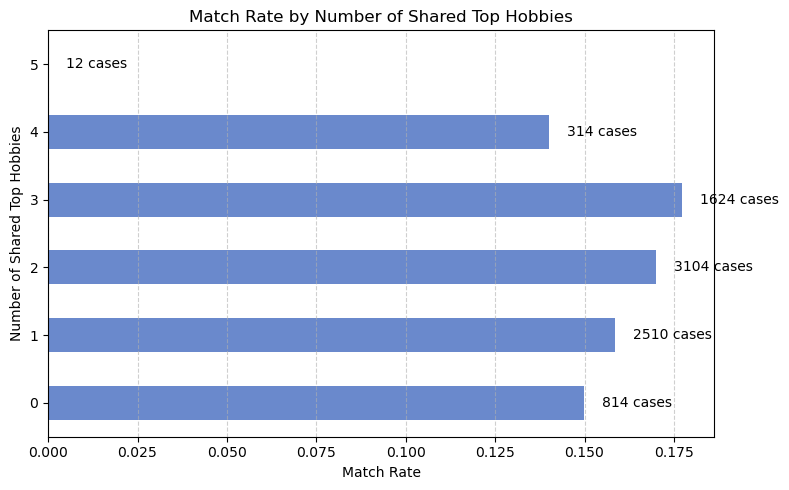

In [25]:
import matplotlib.pyplot as plt

# Agrégation correcte
grouped = shared_hobbies.groupby("nb_shared_top_hobbies").agg(
    match_rate=("match", "mean"),
    count=("match", "count")
).sort_index()

# Forcer l'affichage en entiers si nécessaire
grouped["count"] = grouped["count"].astype(int)

match_rate_by_shared = grouped["match_rate"]
counts_by_shared = grouped["count"]

plt.figure(figsize=(8, 5))
ax = match_rate_by_shared.plot(kind="barh", color="#6A89CC")

# Ajouter les occurrences à droite des barres
for i, (index, row) in enumerate(grouped.iterrows()):
    plt.text(row["match_rate"] + 0.005, i, f"{int(row['count'])} cases", va="center")

plt.xlabel("Match Rate")
plt.ylabel("Number of Shared Top Hobbies")
plt.title("Match Rate by Number of Shared Top Hobbies")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


Surprisingly, the number of shared hobbies appears to have little impact on match rates. In fact, the rate is slightly lower for dates where participants share 4 hobbies in their top 5, and drops to 0% when all 5 hobbies are shared—though this last result is based on only 12 occurrences.

Finally, let’s examine how match rates vary depending on which hobby is considered and whether it is shared by none, one, or both participants.

In [ ]:
# Dataframe initialization
hobby_match_rates = pd.DataFrame(columns=["hobby", "sum_value", "match_rate"])

# Temporary list
results = []

# Define match_rate per hobby, according to the sharing

for col in hobbies_columns:
    for val in [0, 1, 2]:
        subset = shared_hobbies[shared_hobbies[col] == val]
        if not subset.empty:
            results.append({
                "hobby": col.replace("_sum", ""),
                "sum_value": val,
                "match_rate": subset["match"].mean()
            })

hobby_match_rates = pd.DataFrame(results)
hobby_match_rates.head()

,hobby,sum_value,match_rate
0,sports,0,0.161504
1,sports,1,0.164615
2,sports,2,0.173228
3,tvsports,0,0.173313
4,tvsports,1,0.151872


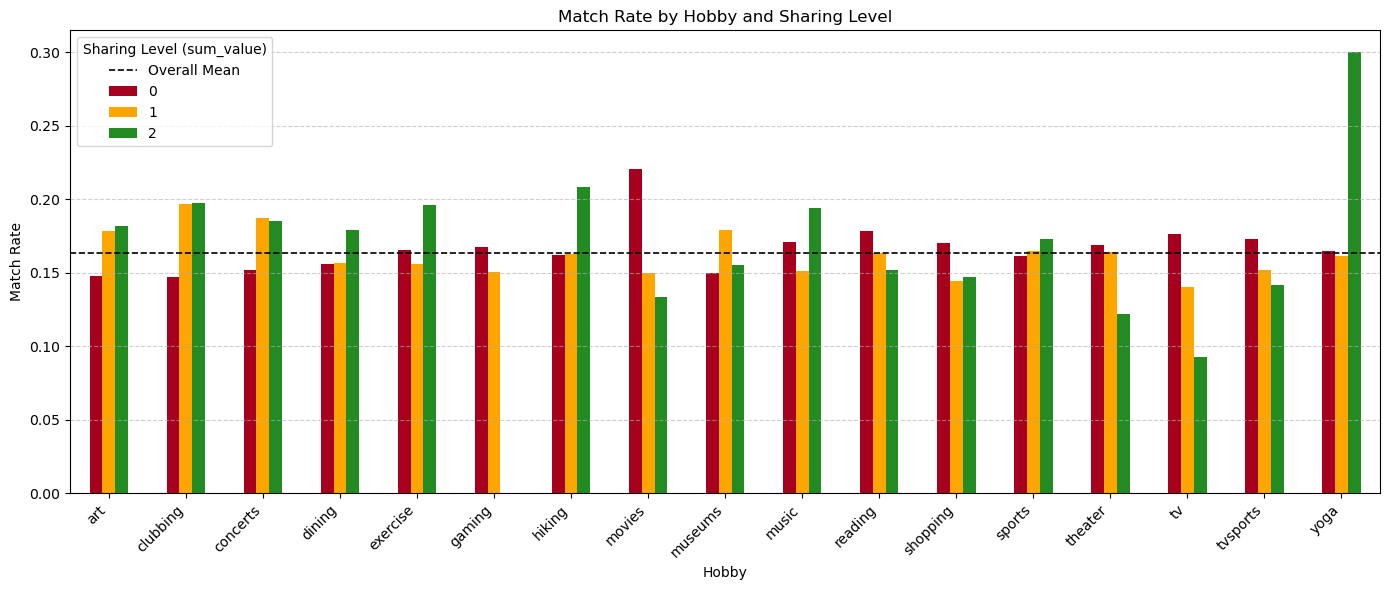

In [ ]:
# Plot the analysis

# Colors dictionnary
color_map = {0: "#A7001E", 1: "#FFA500", 2: "#228B22"}

# Table pivotting
pivot = hobby_match_rates.pivot(index="hobby", columns="sum_value", values="match_rate")

# Overall mean
overall_mean = hobby_match_rates["match_rate"].mean()

# Plot details // axe plot

ax = pivot.plot(kind="bar", color=[color_map.get(x) for x in pivot.columns], figsize=(14, 6))

# Overall mean
plt.axhline(y=overall_mean, color="black", linestyle="--", linewidth=1.2, label="Overall Mean")

# Léegends and labels
plt.title("Match Rate by Hobby and Sharing Level")
plt.ylabel("Match Rate")
plt.xlabel("Hobby")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Sharing Level (sum_value)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

The highest match rates are observed among couples who share a passion for yoga, hiking, clubbing, exercise, or music. Interestingly, not sharing the hobby of watching movies is also associated with a match rate that exceeds the overall average.

## 3.4 The Fatigue Factor: Does Timing Affect Decision-Making?

In [26]:
# Creation of fatigue_df

fatigue_df = df[['iid','pid','match','order','dec','dec_o']].copy()

# Necessary formatting

fatigue_df["iid"] = fatigue_df["iid"].astype("Int64")
fatigue_df["pid"] = fatigue_df["pid"].astype("Int64")

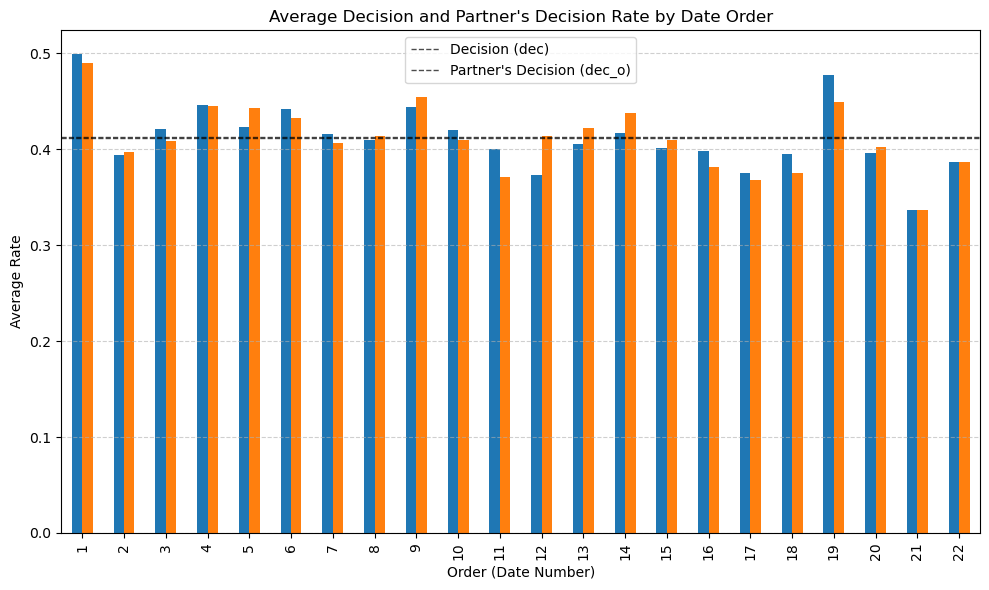

In [31]:
# Plot the positive feedbacks per order

# Means per order
order_grouped = fatigue_df.groupby("order")[["dec", "dec_o"]].mean()
overall_means = order_grouped.mean()

# Plot details
ax = order_grouped.plot(kind="bar", figsize=(10, 6), color=["#1f77b4", "#ff7f0e"])

# Overall mean in horizontal line
for mean in overall_means:
    plt.axhline(y=mean, linestyle="--", linewidth=1, color="black", alpha=0.7)

plt.title("Average Decision and Partner's Decision Rate by Date Order")
plt.ylabel("Average Rate")
plt.xlabel("Order (Date Number)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(["Decision (dec)", "Partner's Decision (dec_o)"])
plt.tight_layout()
plt.show()

This visualization suggests a very slight downward drift over time—only a few percentage points in decision rates—which contributes only partially to the match outcome. However, it reflects only the perspective of the iid and does not account for the potential fatigue of the other participant. Let’s take the analysis a step further to consider both sides of the interaction.

In [32]:
# Add the order of pid in fatigue_both_df

fatigue_both_df = fatigue_df.rename(columns={"order": "order_iid"}).copy()
fatigue_both_df = fatigue_both_df.rename(columns={"dec": "dec_iid", "dec_o": "dec_pid"})
fatigue_both_df["pair_tuple"] = list(zip(fatigue_both_df["iid"], fatigue_both_df["pid"]))

# Create a reversed copy to retrieve the order from the other participant’s perspective.
reversed_df = fatigue_both_df[["iid", "pid", "order_iid"]].copy()
reversed_df.columns = ["pid", "iid", "order_pid"]  # Inverser les rôles
reversed_df["reverse_tuple"] = list(zip(reversed_df["iid"], reversed_df["pid"]))

reversed_df.head()

# Merged on reversed tuple
fatigue_both_df = fatigue_both_df.merge(
    reversed_df[["reverse_tuple", "order_pid"]],
    left_on="pair_tuple",
    right_on="reverse_tuple",
    how="left"
)

# Keep necessary columns
fatigue_both_df = fatigue_both_df.drop(columns=["pair_tuple", "reverse_tuple"])
fatigue_both_df["order_pid"] = fatigue_both_df["order_pid"].astype("Int64")
fatigue_both_df.head(10)



,iid,pid,match,order_iid,dec_iid,dec_pid,order_pid
0,1,11,0,4,1,0,4
1,1,12,0,3,1,0,3
2,1,13,1,10,1,1,10
3,1,14,1,5,1,1,5
4,1,15,1,7,1,1,7
5,1,16,0,6,0,1,6
6,1,17,0,1,1,0,1
7,1,18,0,2,0,0,2
8,1,19,1,8,1,1,8
9,1,20,0,9,1,0,9


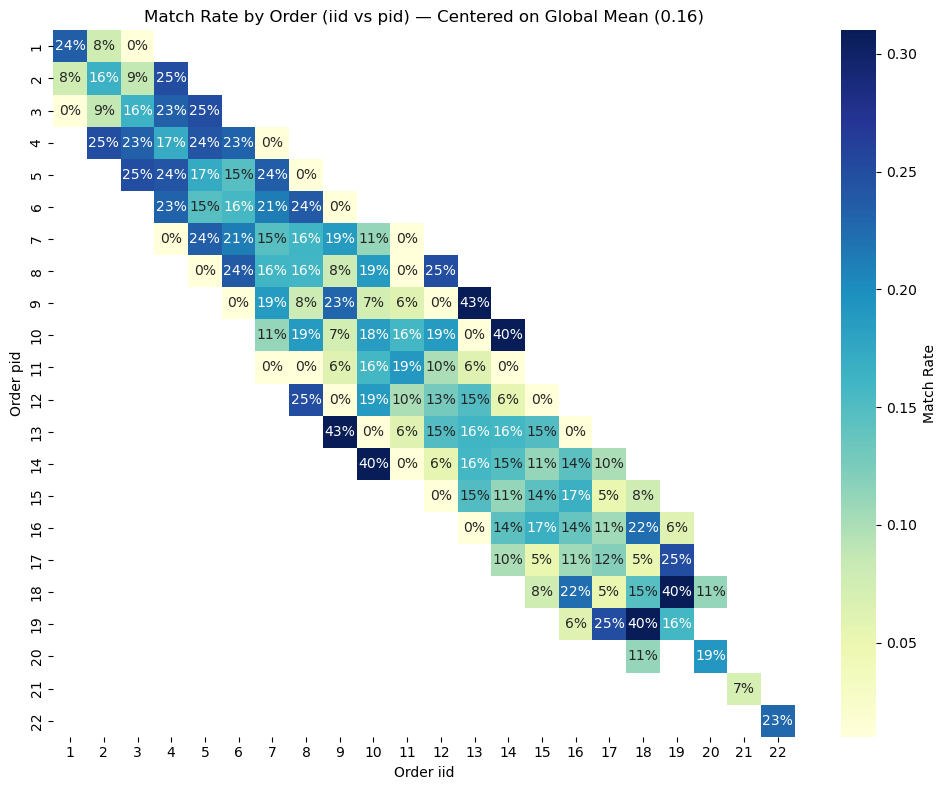

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcul du pivot table
pivot_table = fatigue_both_df.pivot_table(
    index="order_pid",    # lignes
    columns="order_iid",  # colonnes
    values="match",       # taux de match (0 à 1)
    aggfunc="mean"
)

# Définition de l'échelle centrée sur la moyenne
global_mean = 0.16
vmin = global_mean - 0.15
vmax = global_mean + 0.15

# Création d’un tableau d’annotations (formaté en pourcentage)
annot_labels = pivot_table.apply(lambda col: col.map(lambda x: f"{x*100:.0f}%" if pd.notnull(x) else ""), axis=0)

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    data=pivot_table,
    annot=annot_labels,
    fmt="",
    cmap="YlGnBu",
    center=global_mean,
    vmin=vmin,
    vmax=vmax,
    cbar_kws={'label': 'Match Rate'}
)
plt.title(f"Match Rate by Order (iid vs pid) — Centered on Global Mean ({global_mean:.2f})")
plt.xlabel("Order iid")
plt.ylabel("Order pid")
plt.tight_layout()
plt.show()


This visualization suggests that participants are more likely to match earlier in the event, and that match likelihood decreases gradually as both individuals progress through more dates. Shared fatigue or declining enthusiasm over time may be contributing factors. Highlighting these trends with aggregated heat zones or contextual averages would help clarify and support the insight.

Let's try to simplify the visualisation by defining 4 groups

In [38]:
# Defining the categories
def order_group(o):
    if o <= 6:
        return "very early"
    elif o <= 12:
        return "early"
    elif o <= 16:
        return "mid"
    else:
        return "late"

# Applying on the dataframe
fatigue_both_df["order_iid_group"] = fatigue_both_df["order_iid"].apply(order_group)
fatigue_both_df["order_pid_group"] = fatigue_both_df["order_pid"].apply(order_group)

# Display order
order_categories = ["very early", "early", "mid", "late"]

fatigue_both_df.head()

,iid,pid,match,order_iid,dec_iid,dec_pid,order_pid,order_iid_group,order_pid_group
0,1,11,0,4,1,0,4,very early,very early
1,1,12,0,3,1,0,3,very early,very early
2,1,13,1,10,1,1,10,early,early
3,1,14,1,5,1,1,5,very early,very early
4,1,15,1,7,1,1,7,early,early


In [39]:
# Define the good order
fatigue_both_df["order_iid_group"] = pd.Categorical(fatigue_both_df["order_iid_group"], categories=order_categories, ordered=True)
fatigue_both_df["order_pid_group"] = pd.Categorical(fatigue_both_df["order_pid_group"], categories=order_categories, ordered=True)


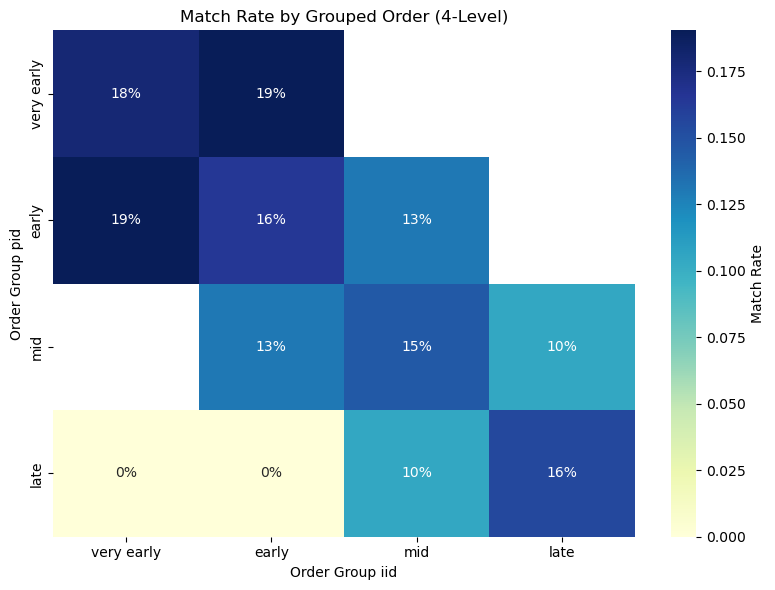

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pivot table
pivot_4groups = fatigue_both_df.pivot_table(
    index="order_pid_group",
    columns="order_iid_group",
    values="match",
    aggfunc="mean",
    observed=False
)

# Création du masque pour cacher les cases sans données
mask = pivot_4groups.isnull()

# Création des annotations (% ou vide)
annot_labels = pivot_4groups.apply(
    lambda col: col.map(lambda x: f"{x*100:.0f}%" if pd.notnull(x) else ""),
    axis=0
)

# Affichage
plt.figure(figsize=(8, 6))
sns.heatmap(
    data=pivot_4groups,
    annot=annot_labels,
    fmt="",
    cmap="YlGnBu",
    mask=mask,  # masque les cases sans données
    cbar_kws={'label': 'Match Rate'}
)
plt.title("Match Rate by Grouped Order (4-Level)")
plt.xlabel("Order Group iid")
plt.ylabel("Order Group pid")
plt.tight_layout()
plt.show()


This confirms that early and very early positions (order ≤ 12) tend to be slightly more favorable for achieving higher match rates compared to later stages of the event.

# 4. Conclusions

## 4.1 Executive summary

The analysis reveals several insightful patterns that can guide strategic improvements to the dating platform's matching process. First, age compatibility plays a significant role: participants are more likely to match when their age difference is small. This suggests value in pre-selecting date pairs within similar age brackets. In terms of user profiles, individuals in the medical and language fields received more positive feedback, while those in engineering performed slightly below average—though this may reflect sampling biases. Furthermore, higher self-perception across key traits—such as attractiveness, intelligence, and humor—is associated with an increased rate of positive responses, likely due to the confidence and likability these individuals project.

Hobby similarity, while often considered crucial, demonstrated little impact overall on match rates—except when participants shared specific key interests such as yoga, hiking, or music. In fact, matches were not more frequent when participants shared all top 5 hobbies, indicating that over-alignment may not foster attraction. Time-related variables also matter: earlier dates (particularly within the first 12 encounters) consistently led to higher match rates. This effect is likely tied to mental fatigue, attention span, and emotional availability during the session.

## 4.2 Business recommandations

- Pre-select Groups by Similar Age Ranges
When organizing events, consider grouping participants into sessions based on narrow age brackets (e.g., 25–30, 31–36). This can be done during registration or by offering targeted time slots. Keeping age ranges tight has been shown to significantly increase match rates.

- Optimize the Order of Encounters
Since earlier rounds yield higher match rates, structure the event to prioritize promising matches at the beginning, include short breaks to maintain energy and engagement, or limit the total number of rounds to focus on quality over quantity.

- Promote Confidence Through Profile Design
Encourage participants to present themselves confidently by structuring profile prompts around positive self-reflection (e.g., “What are you most proud of?” or “What trait do friends admire most in you?”).
Participants with higher self-perception scores tend to receive more positive responses, likely due to the confident and likable impression they project.

- Highlight Key Hobbies in Participant Materials
During check-in or through printed profiles, highlight 2–3 hobbies known to drive compatibility (e.g., yoga, hiking, music). This encourages meaningful conversation and increases the chance of natural connection during short interactions.

- Segment Events by Professional Backgrounds or Interests
Use data from registration forms (e.g., field of study or profession) to create themed events or tables (e.g., healthcare professionals, language enthusiasts). Some participant categories consistently show higher match success and can be emphasized strategically.

- Mitigate Fatigue with Balanced Rotation Design
Avoid pairing participants who are both near the end of their session, as fatigue tends to reduce enthusiasm and match potential. Instead, consider staggered rounds, split-room formats, or energy-refresh elements (like music changes or short pauses) to sustain engagement throughout the event.